In [1]:
import os
import pandas as pd
import pylab as plt
import numpy as np
from scipy.stats import ttest_rel

%matplotlib inline
font = {'size': 14}
plt.rc('font', **font)

/home/alba/.local/lib/python3.9/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.2' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/alba/.local/lib/python3.9/site-packages/pandas/core/arrays/masked.py:59: UserWarning: Pandas requires version '1.3.2' or newer of 'bottleneck' (version '1.2.1' currently installed).
  from pandas.core import (


In [2]:
path = "~/Documents/SACRO/SACRO_experiments_results"
plot_folder = os.path.join(path, "plots")

In [3]:
# %% Load all results files
result_file_names = [x for x in os.listdir(path) if x.endswith('csv')]
result_file_names

['AdaBoost_results.csv',
 'AdaBoost_results_RMP_synthAE_L_XL.csv',
 'DT_entropy_results_in-hospital-mortality.csv',
 'DT_entropy_results_indian_liver.csv',
 'DT_entropy_results_mimic.csv',
 'DT_entropy_results_synth-ae.csv',
 'DT_gini_results_in-hospital-mortality.csv',
 'DT_gini_results_indian_liver.csv',
 'DT_gini_results_mimic.csv',
 'DT_gini_results_synth-ae.csv',
 'RF_100nestimator_results_inHospitalMortality.csv',
 'RF_100nestimator_results_mimic2-iaccd.csv',
 'RF_100nestimator_results_synth-ae.csv',
 'RF_10nestimator_results_in-hospital-mortality.csv',
 'RF_10nestimator_results_indian-liver.csv',
 'RF_10nestimator_results_mimic2-iaccd.csv',
 'RF_10nestimator_results_RDMP.csv',
 'RF_10nestimator_results_synth-ae.csv',
 'RF_200nestimator_results_in-hospital-mortality.csv',
 'RF_200nestimator_results_indian-liver.csv',
 'RF_200nestimator_results_mimic2-iaccd.csv',
 'RF_200nestimator_results_synth-ae.csv',
 'RF_2nestimator_results_in-hospital-mortality.csv',
 'RF_2nestimator_results

In [4]:
results = pd.DataFrame()
for f in result_file_names:
    results = pd.concat([results, pd.read_csv(os.path.join(path,f))], ignore_index=True)

In [5]:
results['dataset'].replace('minmax ','', regex=True, inplace=True)
results

/home/alba/.local/lib/python3.9/site-packages/IPython/lib/pretty.py:778: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  output = repr(obj)
/home/alba/.local/lib/python3.9/site-packages/IPython/core/formatters.py:342: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  return method()


,dataset,scenario,target_classifier,target_clf_file,attack_classifier,attack_clf_file,repetition,target_generalisation_error,model_data_param_id,param_id,...,bootstrap,n_jobs,kernel,C,gamma,probability,booster,use_label_encoder,min_child_weight,verbosity
0,in-hospital-mortality,WorstCase,AdaBoostClassifier,experiments/target_models/a5f0ba74ad525272e248...,RandomForestClassifier(),NaN,0.0,-0.013508,a5f0ba74ad525272e248f64bc2f80da06a1dfc93311274...,53d019d5d477d5f7662b16180b77af4781dbfd869c1b34...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,in-hospital-mortality,WorstCase,AdaBoostClassifier,experiments/target_models/a5f0ba74ad525272e248...,RandomForestClassifier(),NaN,1.0,-0.013508,a5f0ba74ad525272e248f64bc2f80da06a1dfc93311274...,53d019d5d477d5f7662b16180b77af4781dbfd869c1b34...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,in-hospital-mortality,WorstCase,AdaBoostClassifier,experiments/target_models/a5f0ba74ad525272e248...,RandomForestClassifier(),NaN,2.0,-0.013508,a5f0ba74ad525272e248f64bc2f80da06a1dfc93311274...,53d019d5d477d5f7662b16180b77af4781dbfd869c1b34...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,in-hospital-mortality,WorstCase,AdaBoostClassifier,experiments/target_models/a5f0ba74ad525272e248...,RandomForestClassifier(),NaN,3.0,-0.013508,a5f0ba74ad525272e248f64bc2f80da06a1dfc93311274...,53d019d5d477d5f7662b16180b77af4781dbfd869c1b34...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,in-hospital-mortality,WorstCase,AdaBoostClassifier,experiments/target_models/a5f0ba74ad525272e248...,RandomForestClassifier(),NaN,4.0,-0.013508,a5f0ba74ad525272e248f64bc2f80da06a1dfc93311274...,53d019d5d477d5f7662b16180b77af4781dbfd869c1b34...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
628187,synth-ae,WorstCase,XGBClassifier,experiments/target_models/54784baac9ce0c803378...,RandomForestClassifier(),NaN,7.0,-0.147619,54784baac9ce0c8033783f226995b632c663add0a18647...,1126fcd8559cea9713ef3d9178a0c0f5c691e0f7c6cb55...,...,NaN,NaN,NaN,NaN,NaN,NaN,dart,False,0.0,0.0
628188,synth-ae,WorstCase,XGBClassifier,experiments/target_models/54784baac9ce0c803378...,RandomForestClassifier(),NaN,8.0,-0.147619,54784baac9ce0c8033783f226995b632c663add0a18647...,1126fcd8559cea9713ef3d9178a0c0f5c691e0f7c6cb55...,...,NaN,NaN,NaN,NaN,NaN,NaN,dart,False,0.0,0.0
628189,synth-ae,WorstCase,XGBClassifier,experiments/target_models/54784baac9ce0c803378...,RandomForestClassifier(),NaN,9.0,-0.147619,54784baac9ce0c8033783f226995b632c663add0a18647...,1126fcd8559cea9713ef3d9178a0c0f5c691e0f7c6cb55...,...,NaN,NaN,NaN,NaN,NaN,NaN,dart,False,0.0,0.0
628190,synth-ae,lira,XGBClassifier,experiments/target_models/54784baac9ce0c803378...,XGBClassifier,NaN,NaN,-0.147619,54784baac9ce0c8033783f226995b632c663add0a18647...,1126fcd8559cea9713ef3d9178a0c0f5c691e0f7c6cb55...,...,NaN,NaN,NaN,NaN,NaN,NaN,dart,False,0.0,0.0


In [6]:
results.columns

Index(['dataset', 'scenario', 'target_classifier', 'target_clf_file',
       'attack_classifier', 'attack_clf_file', 'repetition',
       'target_generalisation_error', 'model_data_param_id', 'param_id',
       'n_estimators', 'algorithm', 'attack_TPR', 'attack_FPR', 'attack_FAR',
       'attack_TNR', 'attack_PPV', 'attack_NPV', 'attack_FNR', 'attack_ACC',
       'attack_F1score', 'attack_Advantage', 'attack_AUC',
       'attack_P_HIGHER_AUC', 'attack_FMAX01', 'attack_FMIN01',
       'attack_FDIF01', 'attack_PDIF01', 'attack_FMAX02', 'attack_FMIN02',
       'attack_FDIF02', 'attack_PDIF02', 'attack_FMAX001', 'attack_FMIN001',
       'attack_FDIF001', 'attack_PDIF001', 'attack_pred_prob_var',
       'attack_TPR@0.5', 'attack_TPR@0.2', 'attack_TPR@0.1', 'attack_TPR@0.01',
       'attack_TPR@0.001', 'attack_TPR@1e-05', 'attack_n_pos_test_examples',
       'attack_n_neg_test_examples', 'mia_hyp_min_samples_split',
       'mia_hyp_min_samples_leaf', 'mia_hyp_max_depth', 'criterion',
       

In [7]:
results['target_classifier'] = [" ".join(x) for x in zip(list(results.target_classifier), list(results.kernel.fillna('')))]

In [8]:
# %% Define the filter function (useful below)
def filter_df(df, conditions):
    return_df = df.copy()
    for condition_col, condition_val in conditions.items():
        return_df = return_df[return_df[condition_col] == condition_val]
    return return_df

['AdaBoostClassifier ' 'DecisionTreeClassifier ' 'RandomForestClassifier '
 'SVC rbf' 'XGBClassifier ']


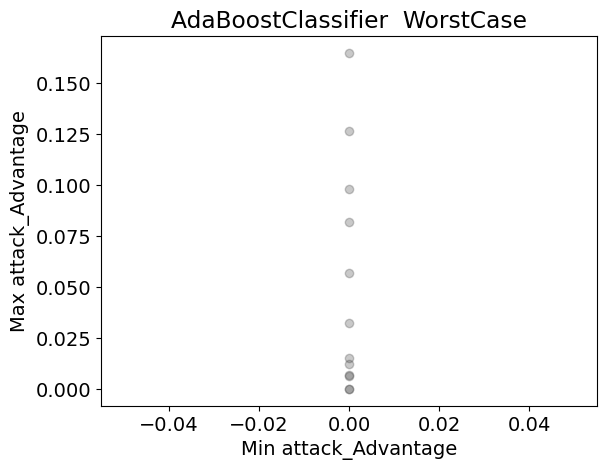

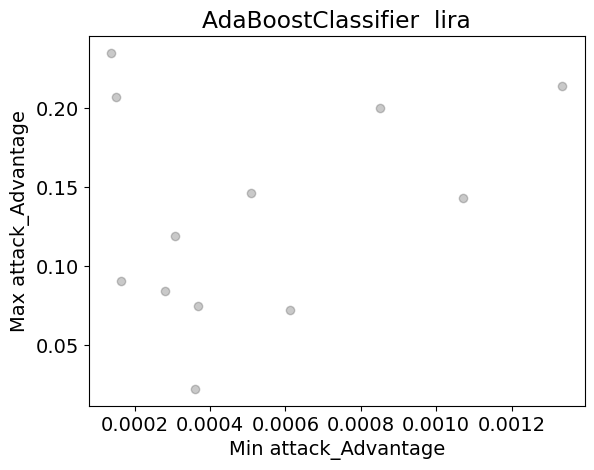

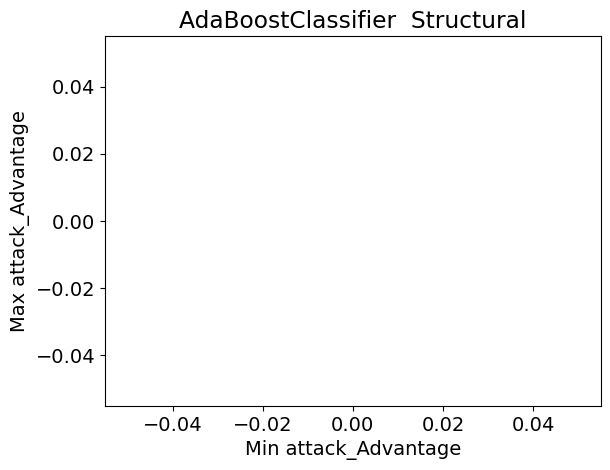

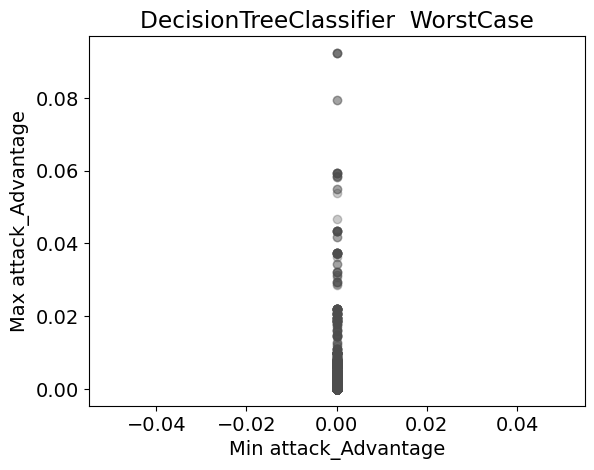

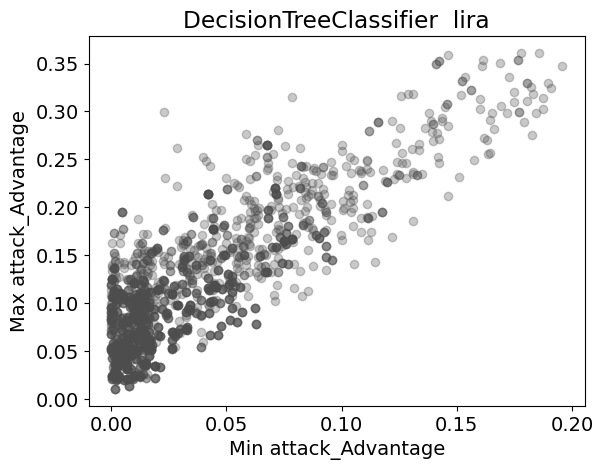

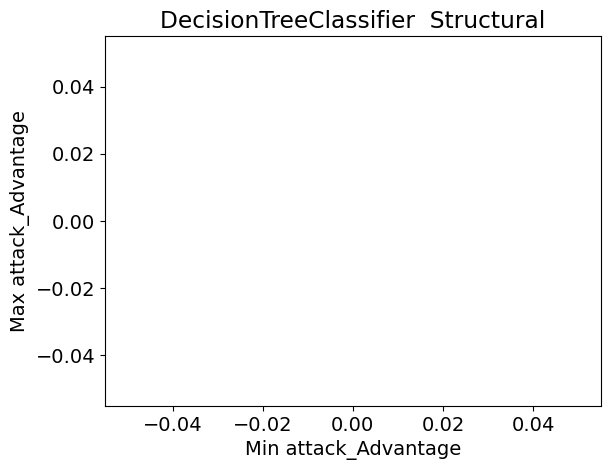

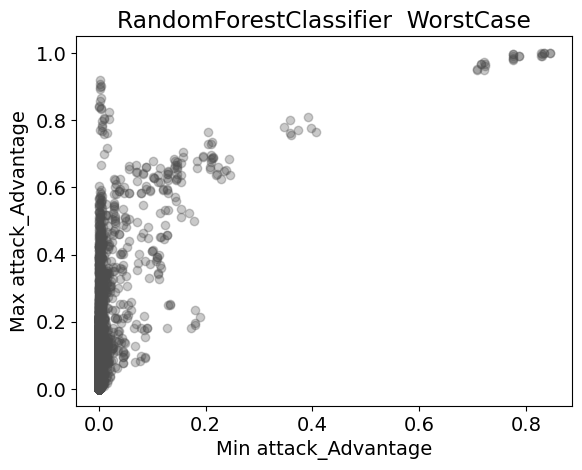

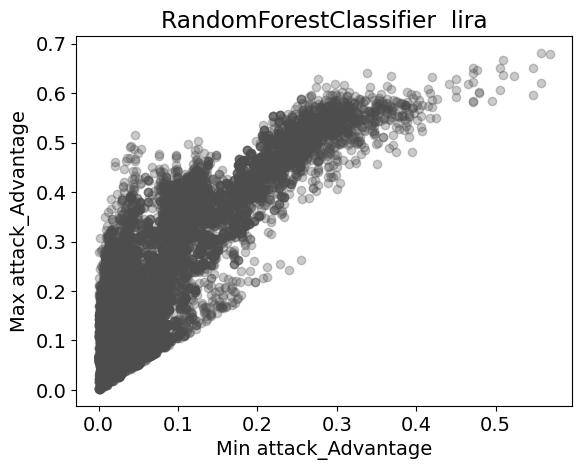

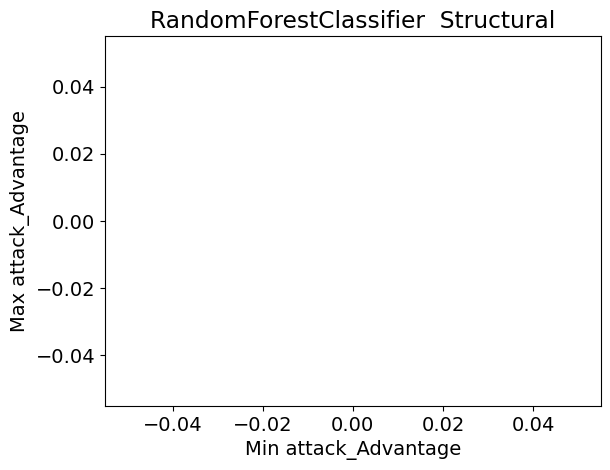

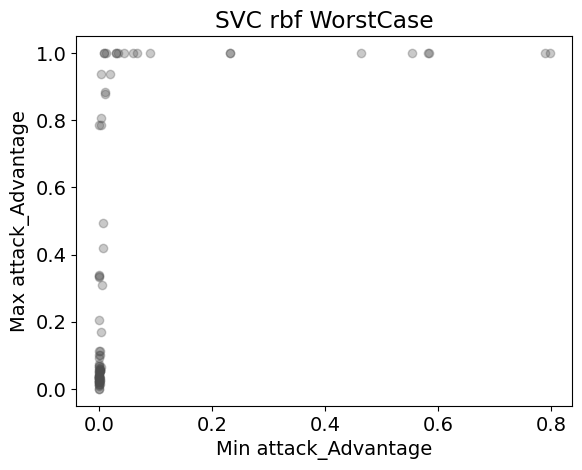

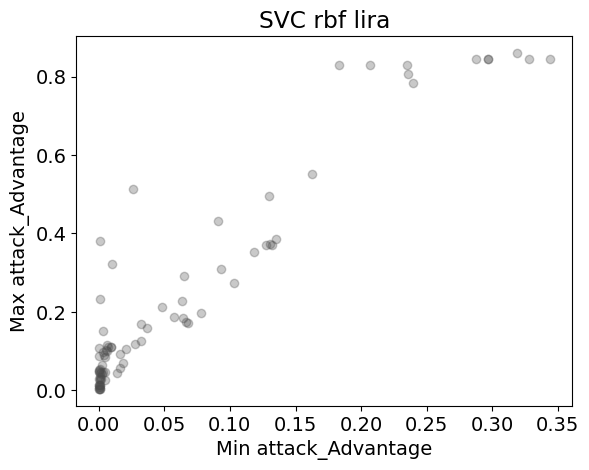

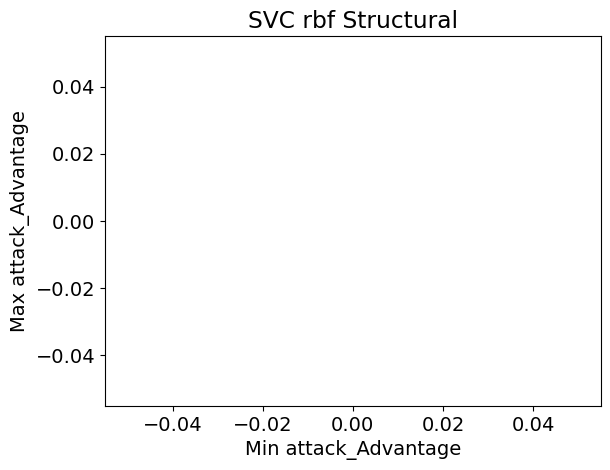

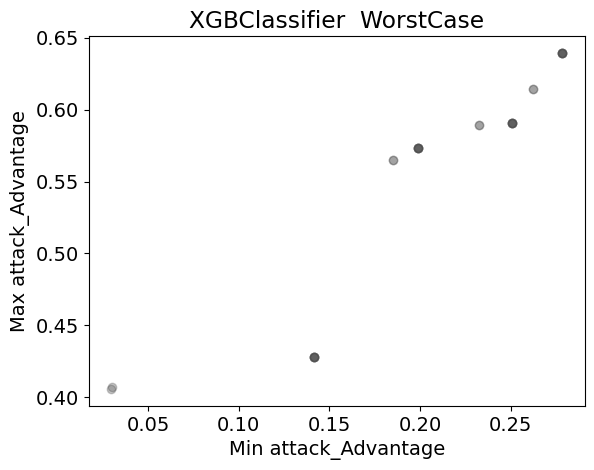

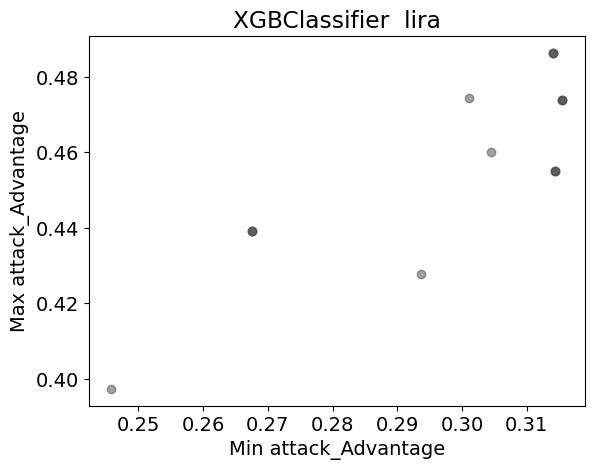

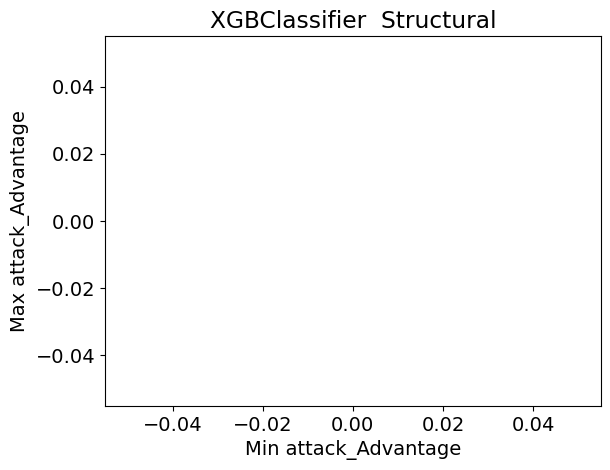

In [9]:
# %% Risk isn't generalisable
# Look at the range of a metric for the same params across datasets
# Makes plots for each classifier that show, for each set of hyper-params, the
# min versus max value of the metric.
# Set metric to be the metric wanted
metric = 'attack_Advantage'
classifiers = results['target_classifier'].unique()
print(classifiers)
scenarios =  results['scenario'].unique()
for classifier in classifiers:
    for scenario in scenarios:
        sub = filter_df(results, {'target_classifier': classifier, 'scenario': scenario})
        pid = sub['param_id'].unique()
        temp = sub.groupby(['param_id', 'dataset']).agg(
            mean_metric = pd.NamedAgg(column=metric, aggfunc=np.mean)
        ).reset_index().groupby('param_id').agg(
            max_metric = pd.NamedAgg(column='mean_metric', aggfunc=max),
            min_metric = pd.NamedAgg(column='mean_metric', aggfunc=min)
        )
        temp['diff'] = temp['max_metric'] - temp['min_metric']
        plt.figure()
        plt.scatter(temp['min_metric'], temp['max_metric'], color=[0.3, 0.3, 0.3, 0.3])
        plt.xlabel(f'Min {metric}')
        plt.ylabel(f'Max {metric}')
        plt.title(f'{classifier} {scenario}')
        clf = classifier.split(' ')[0]
        plot_name = os.path.join(plot_folder, f'{clf}_{metric}_{scenario}_range.png')
        plt.savefig(plot_name)

In [10]:
# %% Comparing performance across scenarios
# plot the difference for paired samples (same hyp, different scenarios)
# %% Useful method to plot a comparison of scenarios
def comparison(results_df, metric, conditions, scenario_1, scenario_2, plot=True, save_plot=None):
    if len(conditions) > 0:
        sub_df = filter_df(results_df, conditions)[['param_id', metric, 'scenario']]
    else:
        sub_df = results_df
    pivoted = pd.pivot_table(sub_df, index=['param_id'], values=[metric], columns=['scenario'])
    pivoted.reset_index(inplace=True)
    if plot:
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.hist(pivoted[metric][scenario_1] - pivoted[metric][scenario_2])
        plt.title(' '.join(conditions.values()))
        plt.xlabel(f'{metric}: {scenario_1} - {scenario_2}')
        plt.subplot(1, 2, 2)
        plt.scatter(pivoted[metric][scenario_1], pivoted[metric][scenario_2], alpha=0.2)
        xl = plt.xlim()
        yl = plt.ylim()
        mi = min([xl[0], yl[0]])
        ma = max([xl[1], yl[1]])
        plt.plot([mi, ma], [mi, ma], 'k--')
        plt.xlabel(f'{scenario_1} {metric}')
        plt.ylabel(f'{scenario_2} {metric}')
        plt.title(' '.join(conditions.values()))
        if save_plot is not None:
            plt.savefig(save_plot)
    _, p_1_gt_2 = ttest_rel(pivoted[metric][scenario_1], pivoted[metric][scenario_2], alternative='greater')
    _, p_2_gt_1 = ttest_rel(pivoted[metric][scenario_2], pivoted[metric][scenario_1], alternative='greater')

In [11]:
# Filter out some of the meaningless results
#filtered_res = results[results['target_train_pred_prob_var'] > 1e-2]

/tmp/ipykernel_160/615006760.py:12: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(figsize=(12, 5))


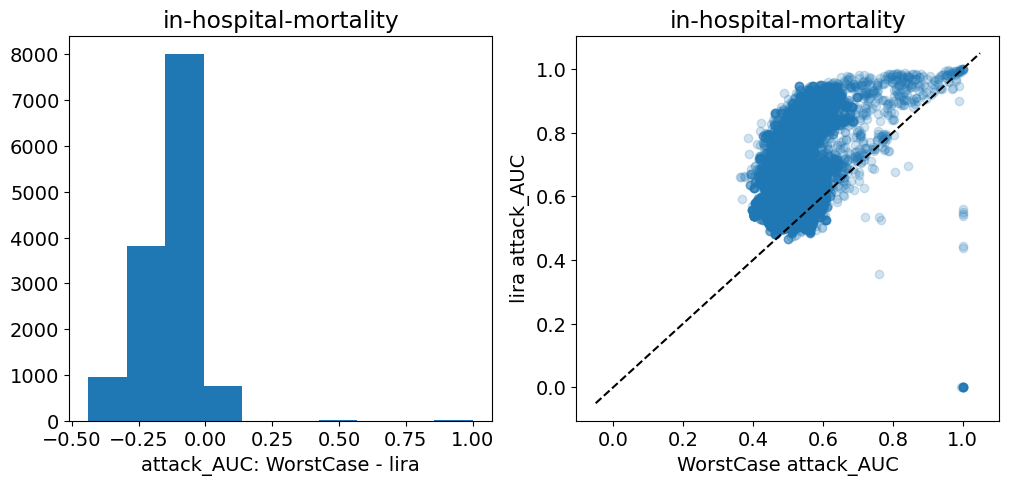

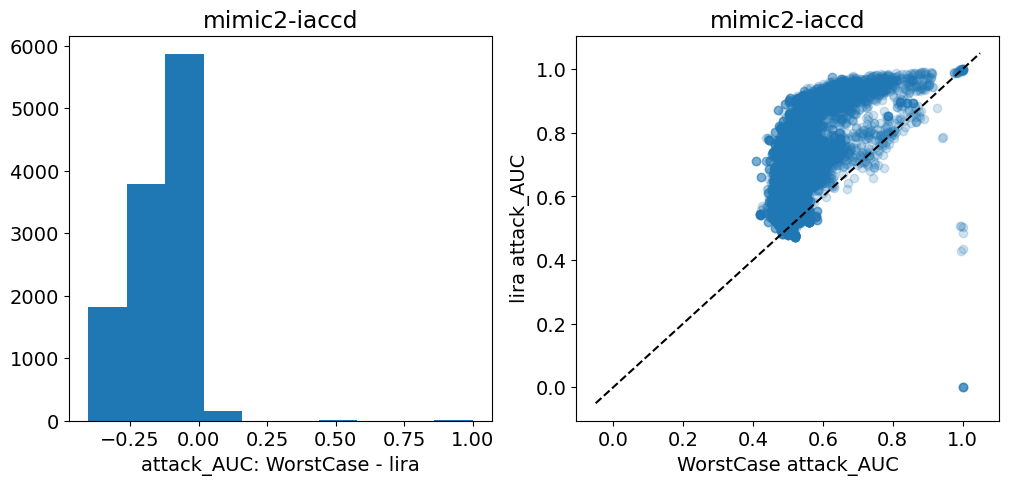

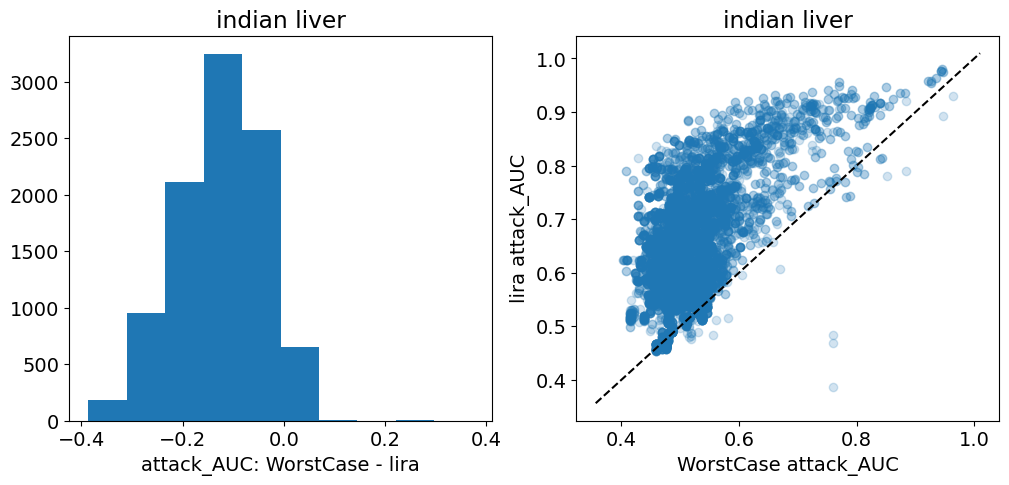

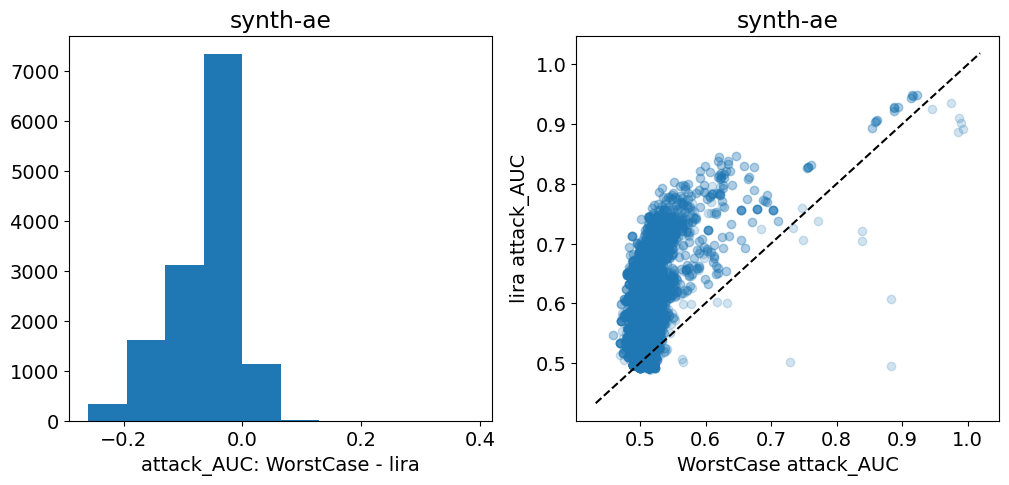

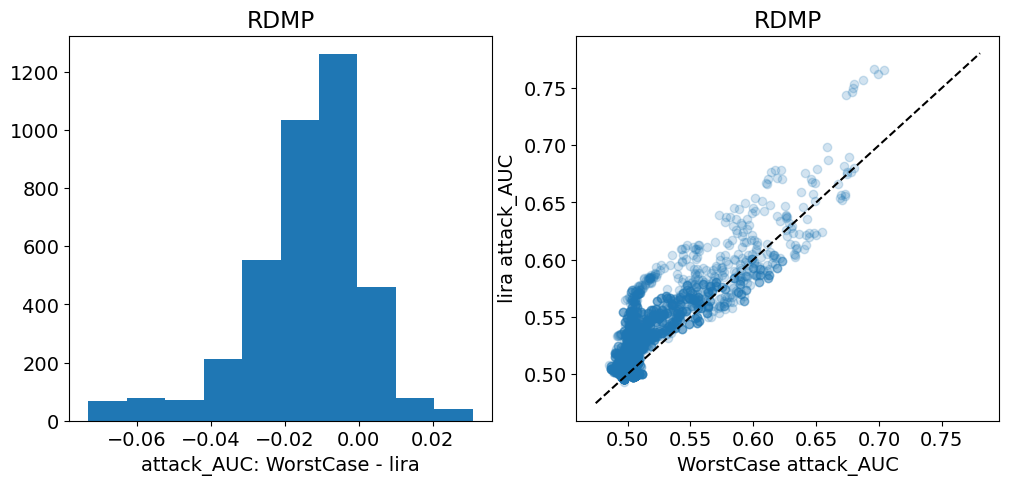

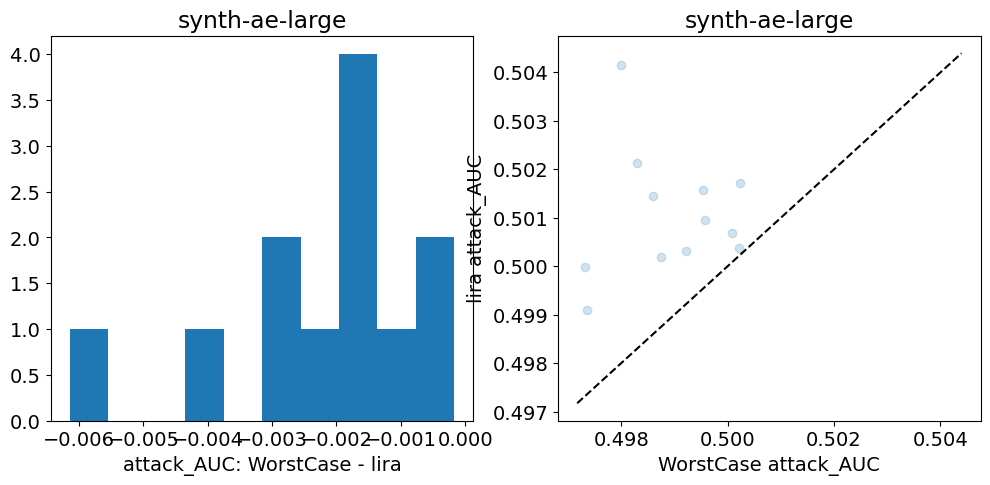

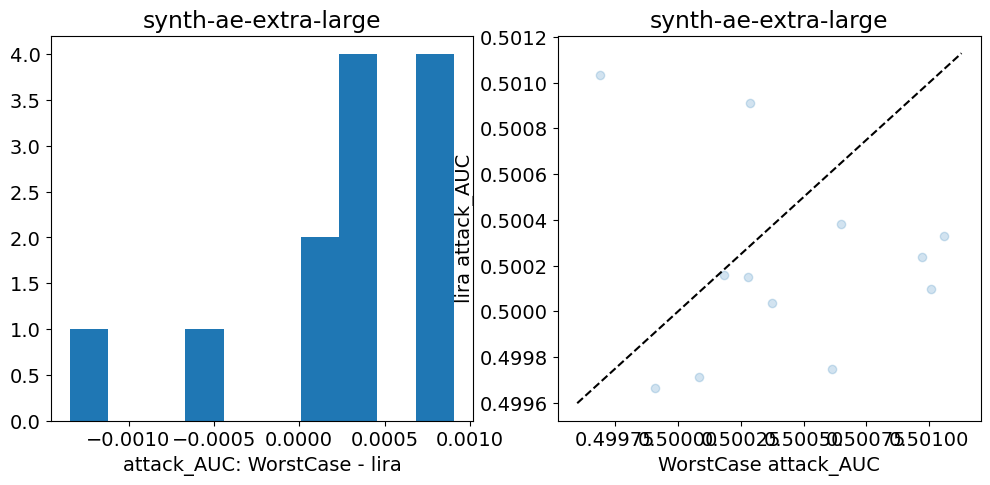

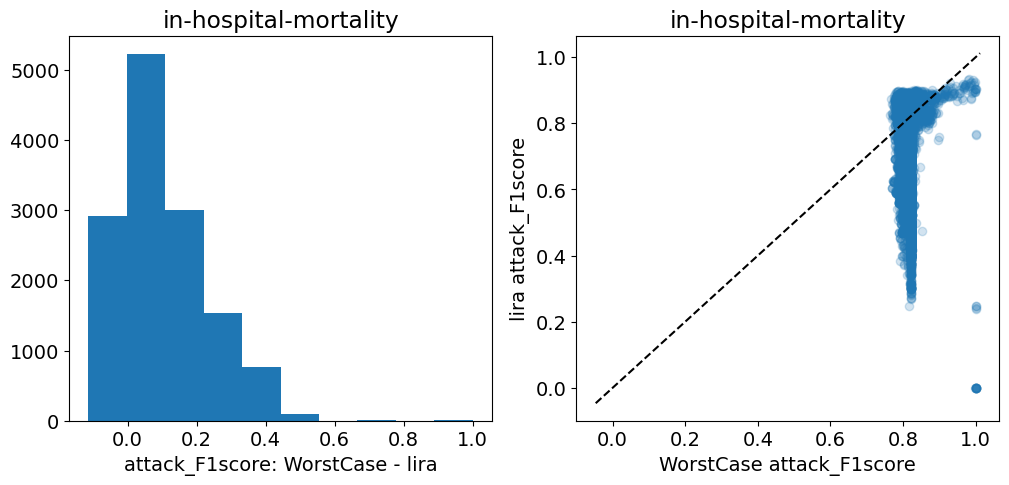

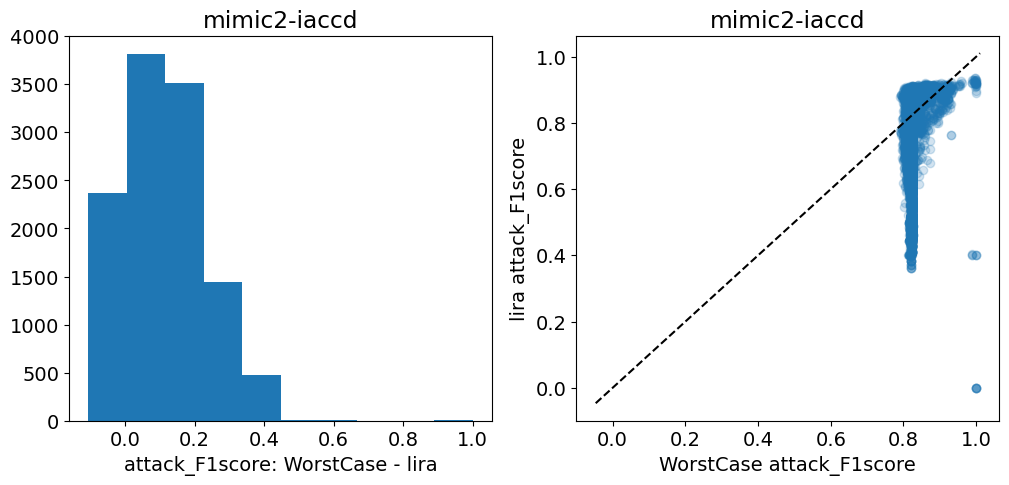

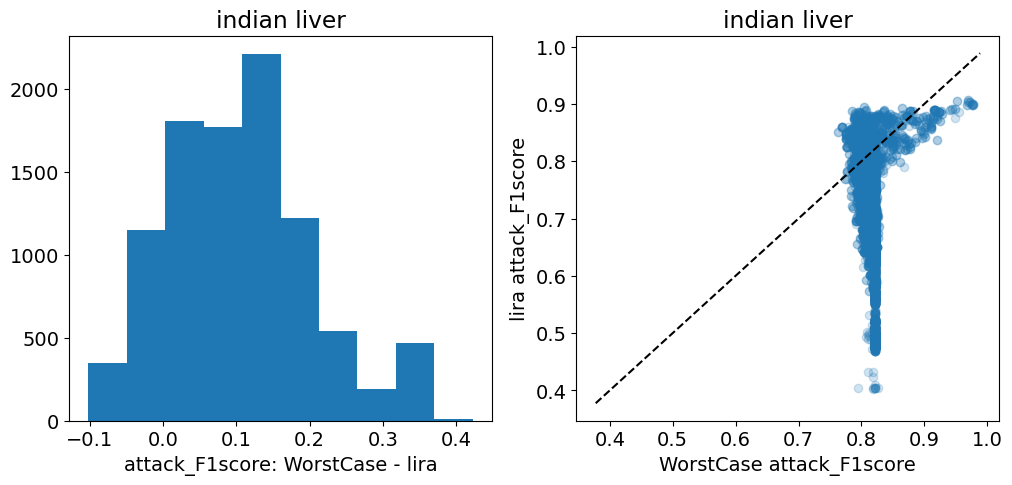

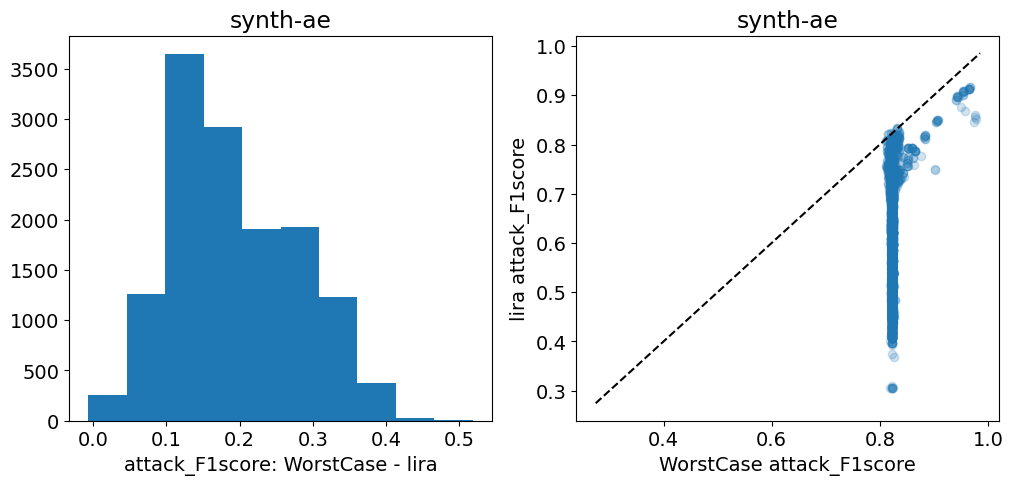

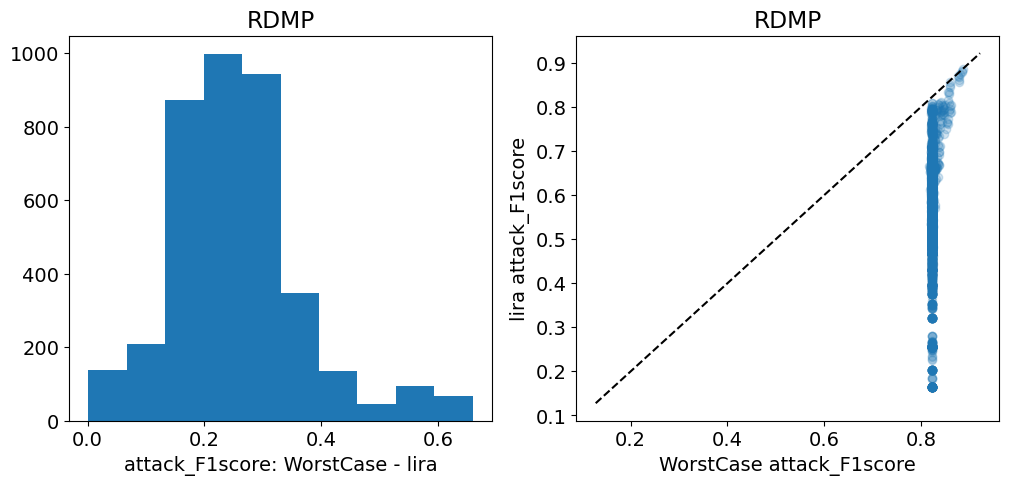

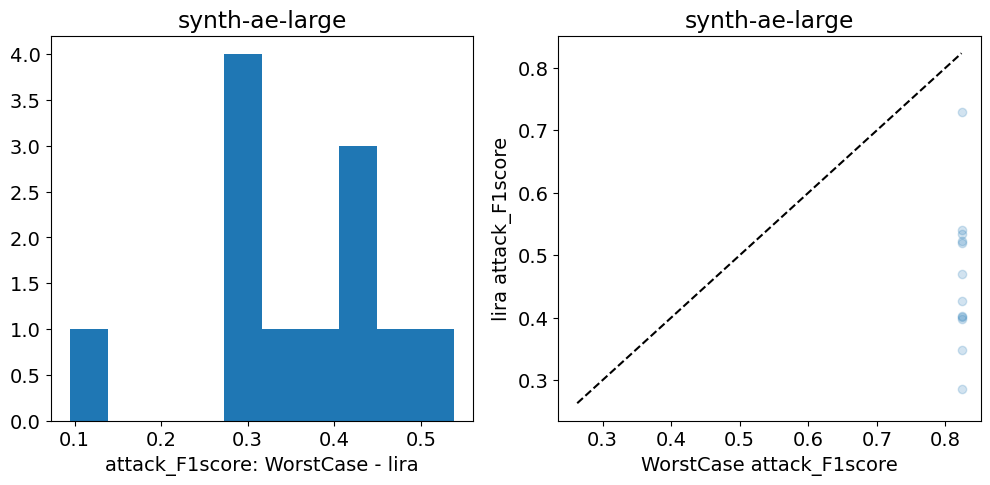

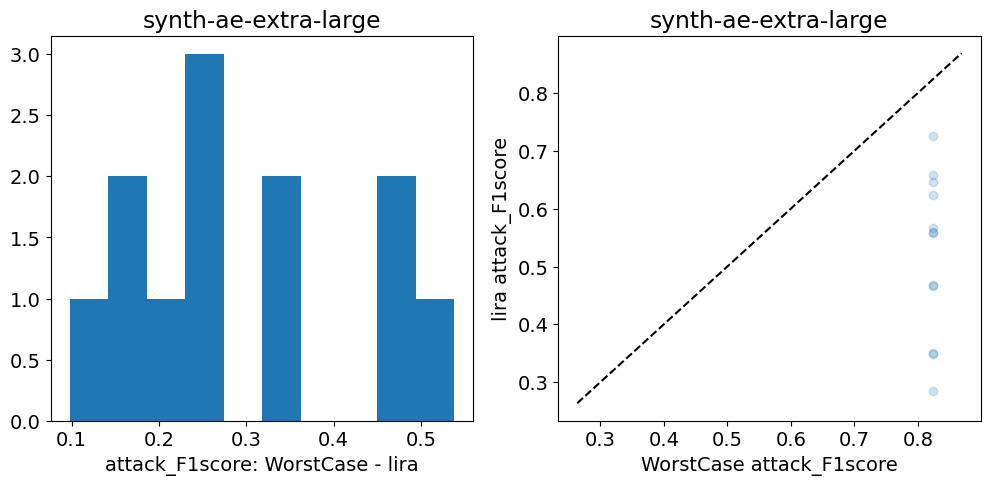

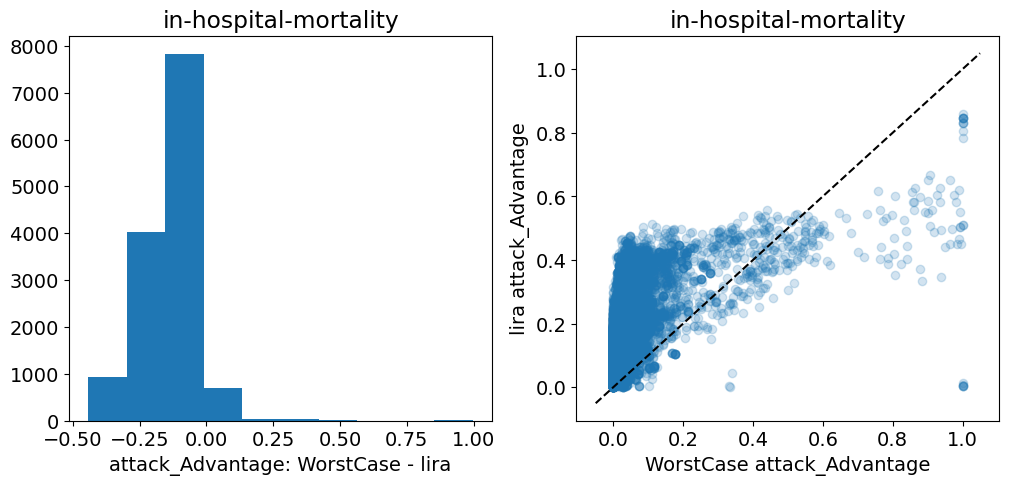

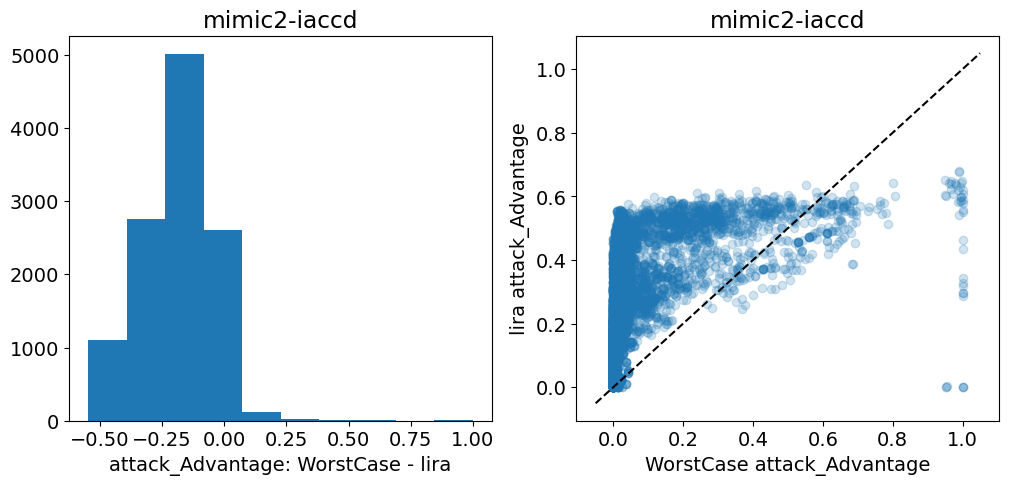

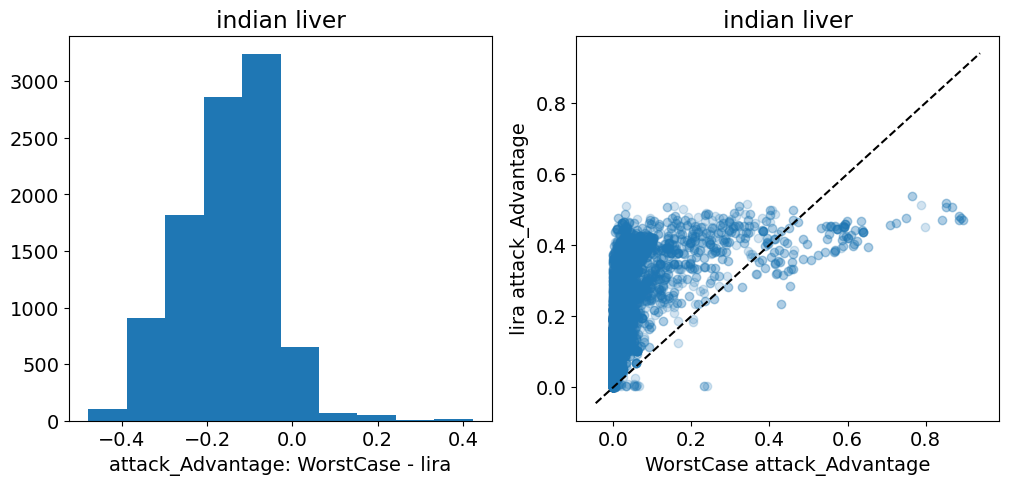

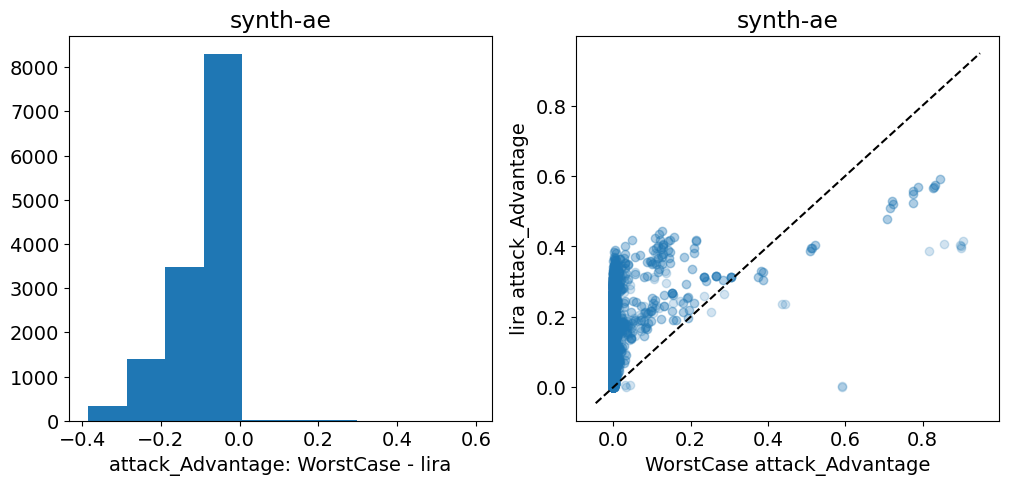

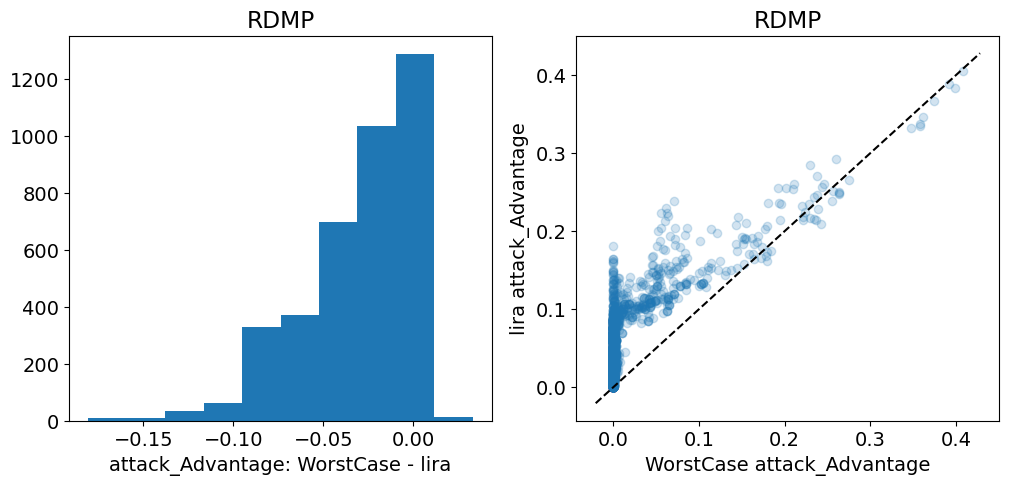

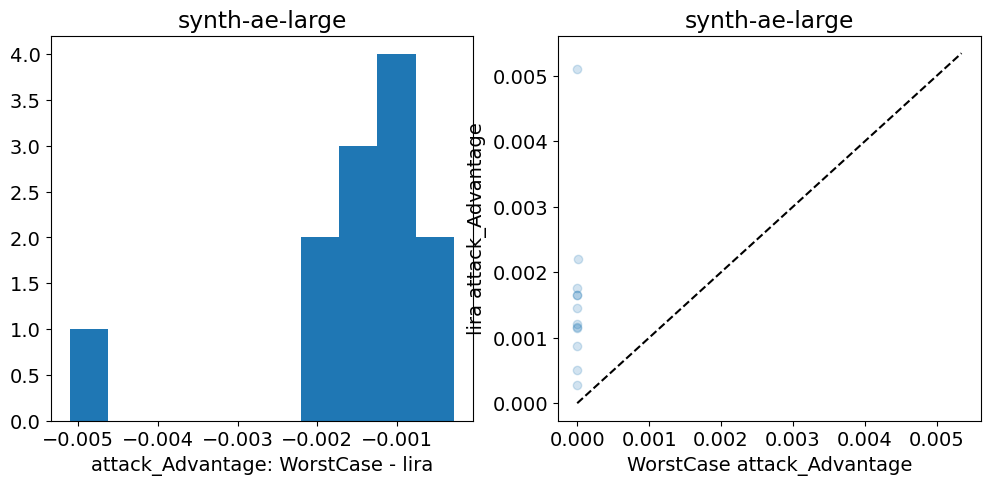

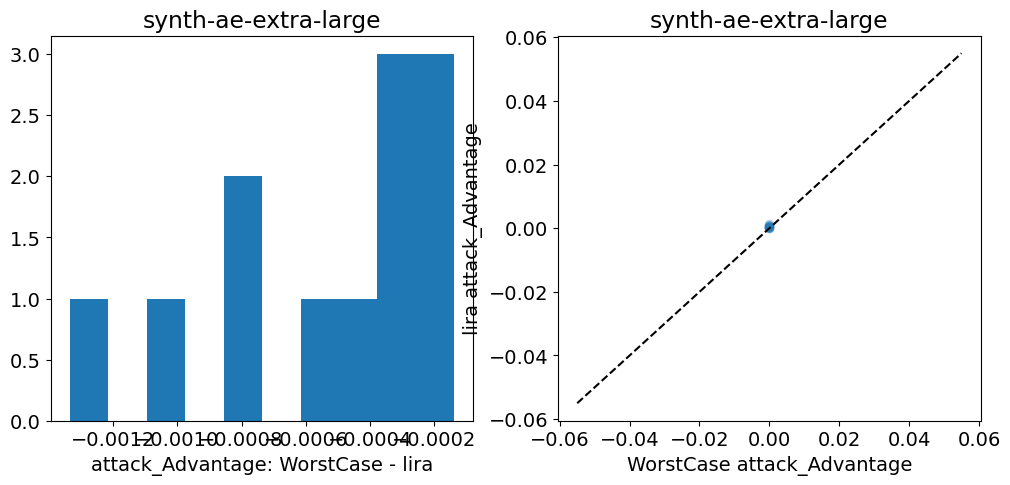

In [12]:
# Plot each metric for each dataset
plot_metrics = ['attack_AUC', 'attack_F1score', 'attack_Advantage']
for metric in plot_metrics:
    # conditions = {'dataset': 'synth-ae', 'target_classifier': 'XGBClassifier '}
    # conditions = {'dataset': 'mimic2-iaccd'}
    conditions = {}
    for dataset in results.dataset.unique():
        #if 'mimic2-iaccd' in dataset:
        #    continue
        conditions['dataset'] = dataset
        tmp_res = results.groupby(['dataset', 'scenario', 'target_classifier', 'param_id']).mean(['repetition'])
        tmp_res.reset_index(inplace=True)
        plot_file = os.path.join(plot_folder, f'{dataset}_{metric}.png')
        p = comparison(tmp_res, metric, conditions, 'WorstCase', 'lira', save_plot=plot_file)

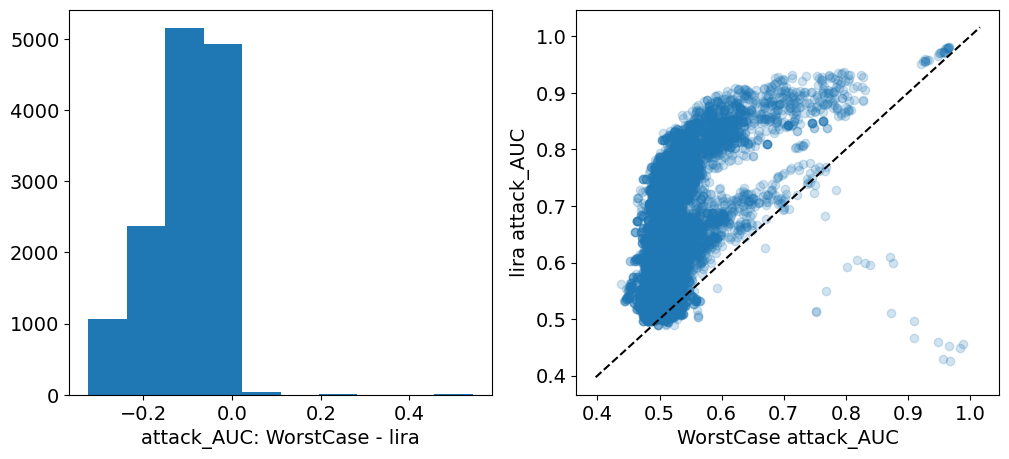

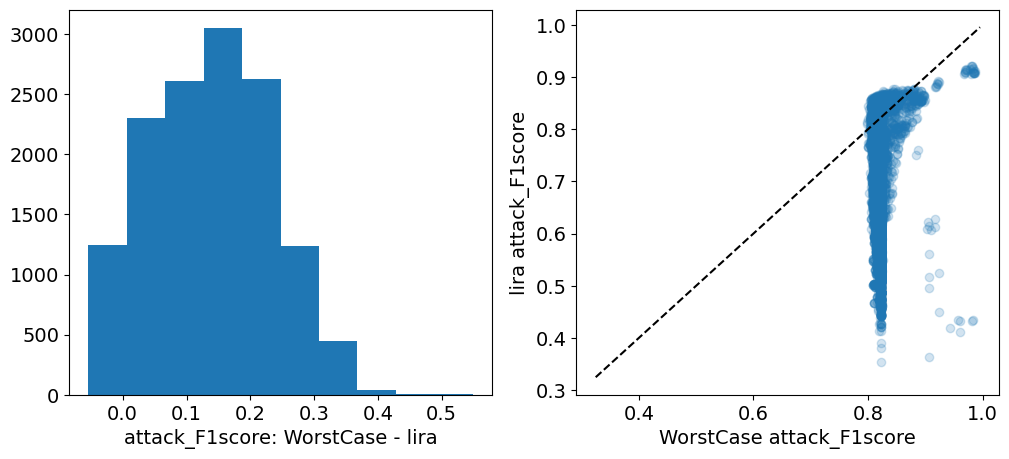

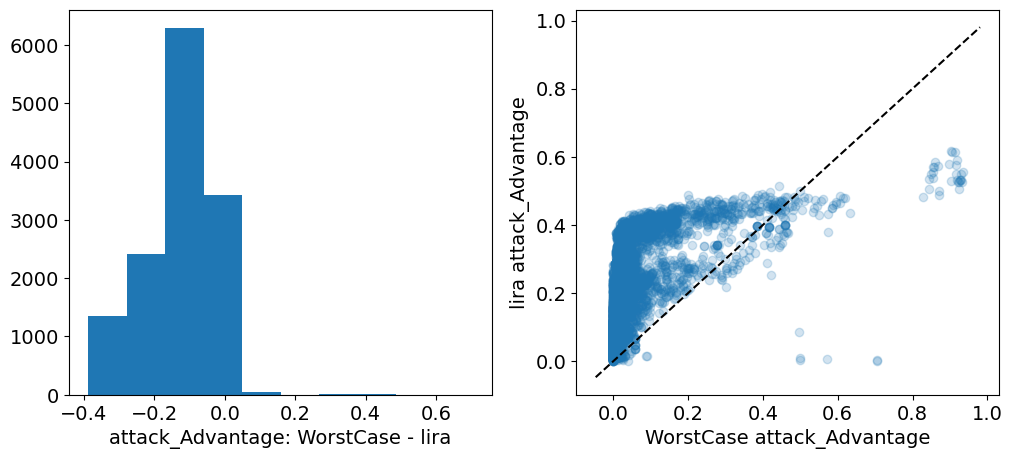

In [13]:
# %% The same plot, but for all datasets together
conditions = {}
for metric in plot_metrics:
    plot_file = os.path.join(plot_folder, f'{metric}.png')
    p = comparison(results, metric, conditions, 'WorstCase', 'lira', save_plot=plot_file)